In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Exploration:

In [2]:
data_train = pd.read_csv('Titanic_train.csv')# loading the dataset of titanic train
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data_test = pd.read_csv('Titanic_test.csv')# loading the dataset of titanic test
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Performing EDA 

In [4]:
# for titanic train data
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data_train.fillna({'Age' : data_train['Age'].median()},inplace=True)

In [7]:
# droping cabin column due to more than 70% values are nan
data_train.drop(columns='Cabin',inplace=True)

In [8]:
data_train.fillna({'Embarked' : data_train['Embarked'].mode()[0]},inplace=True)

In [9]:
data_train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [11]:
data_train.duplicated().sum()

np.int64(0)

In [12]:
data_train.shape

(891, 11)

In [13]:
data_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [14]:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
data_train_numeric=data_train._get_numeric_data()

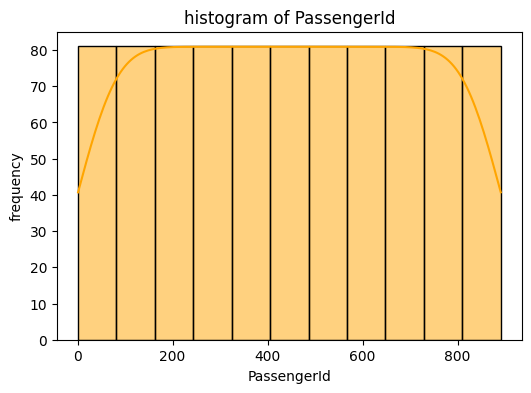

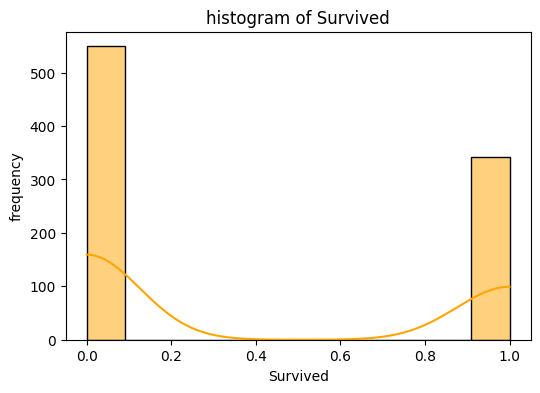

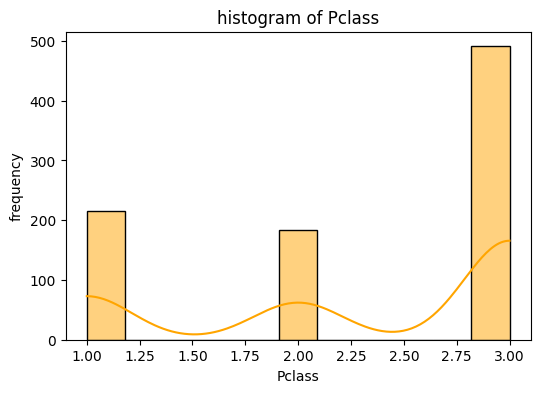

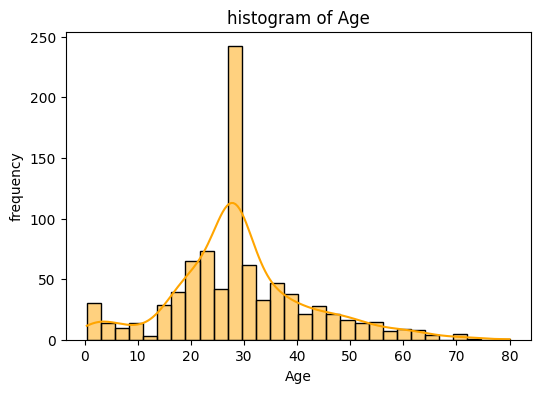

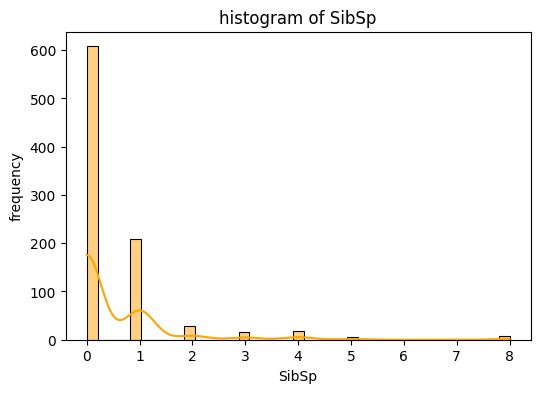

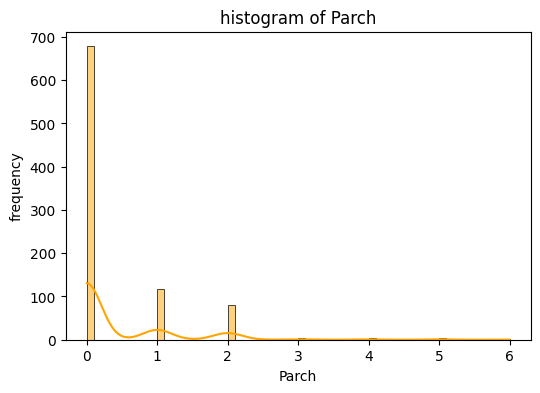

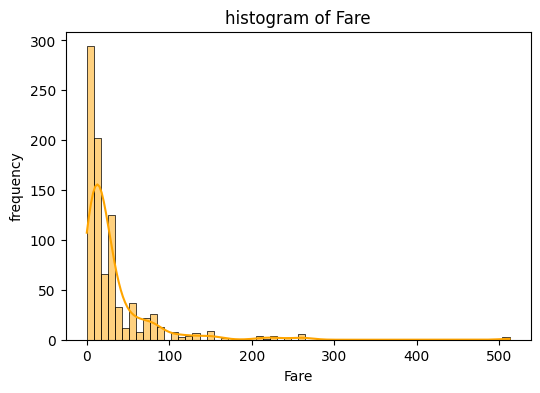

In [16]:
#creating histogram

for col in data_train_numeric.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data_train[col],kde=True,color='orange',edgecolor='black')
    plt.title(f'histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

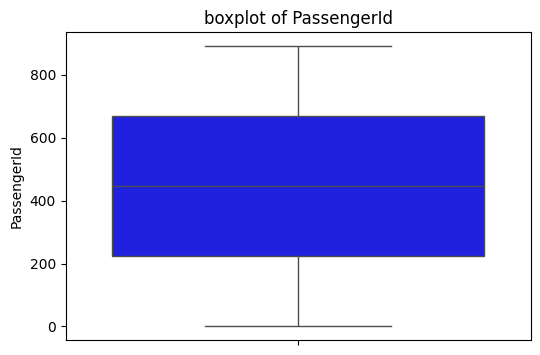

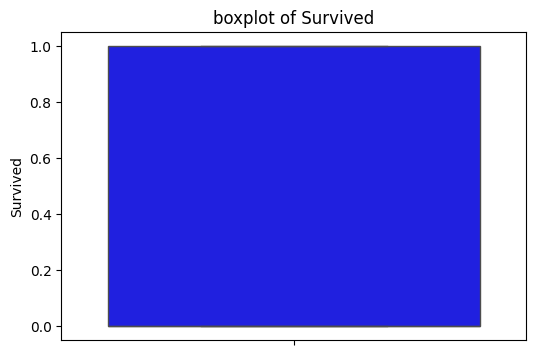

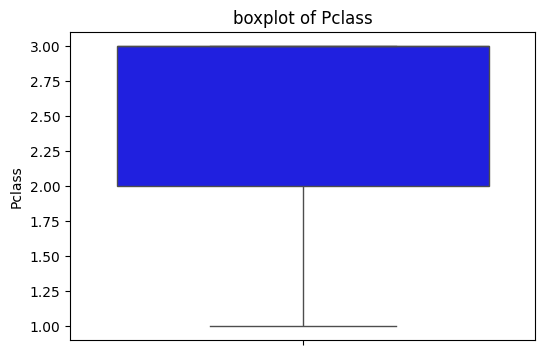

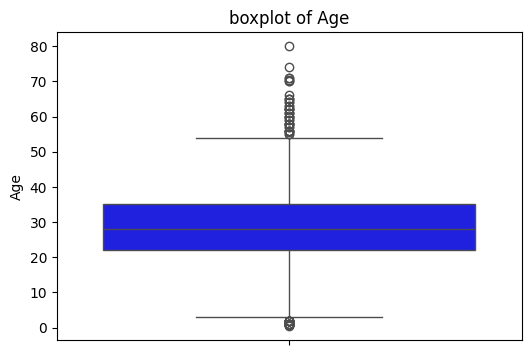

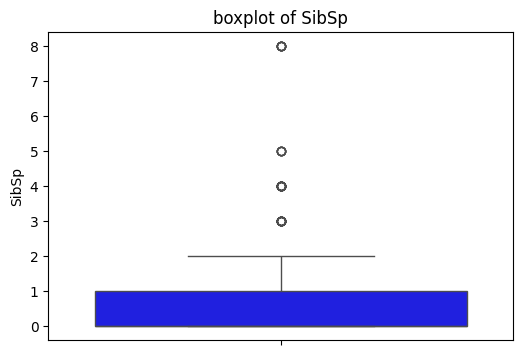

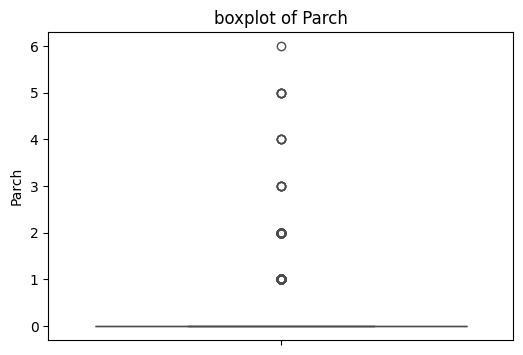

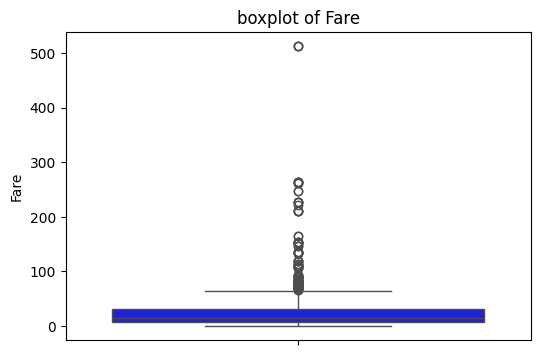

In [17]:
#Create boxplots for to identify outliers.

for col in data_train_numeric.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data_train[col],color='blue')
    plt.title(f'boxplot of {col}')
    plt.show()

In [18]:
data_train_non_numeric=data_train.drop(data_train_numeric,axis=1)

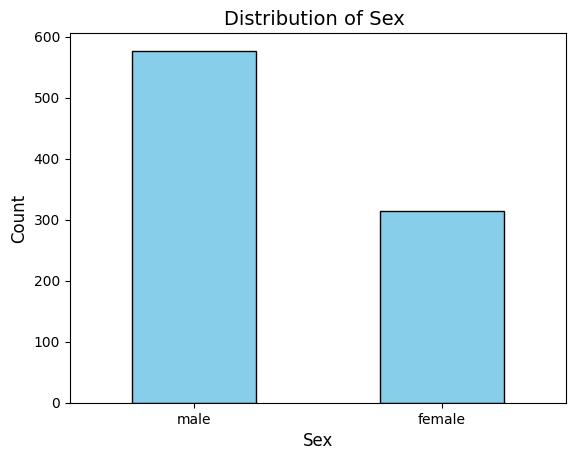

In [19]:
data_train['Sex'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Sex ', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.show()

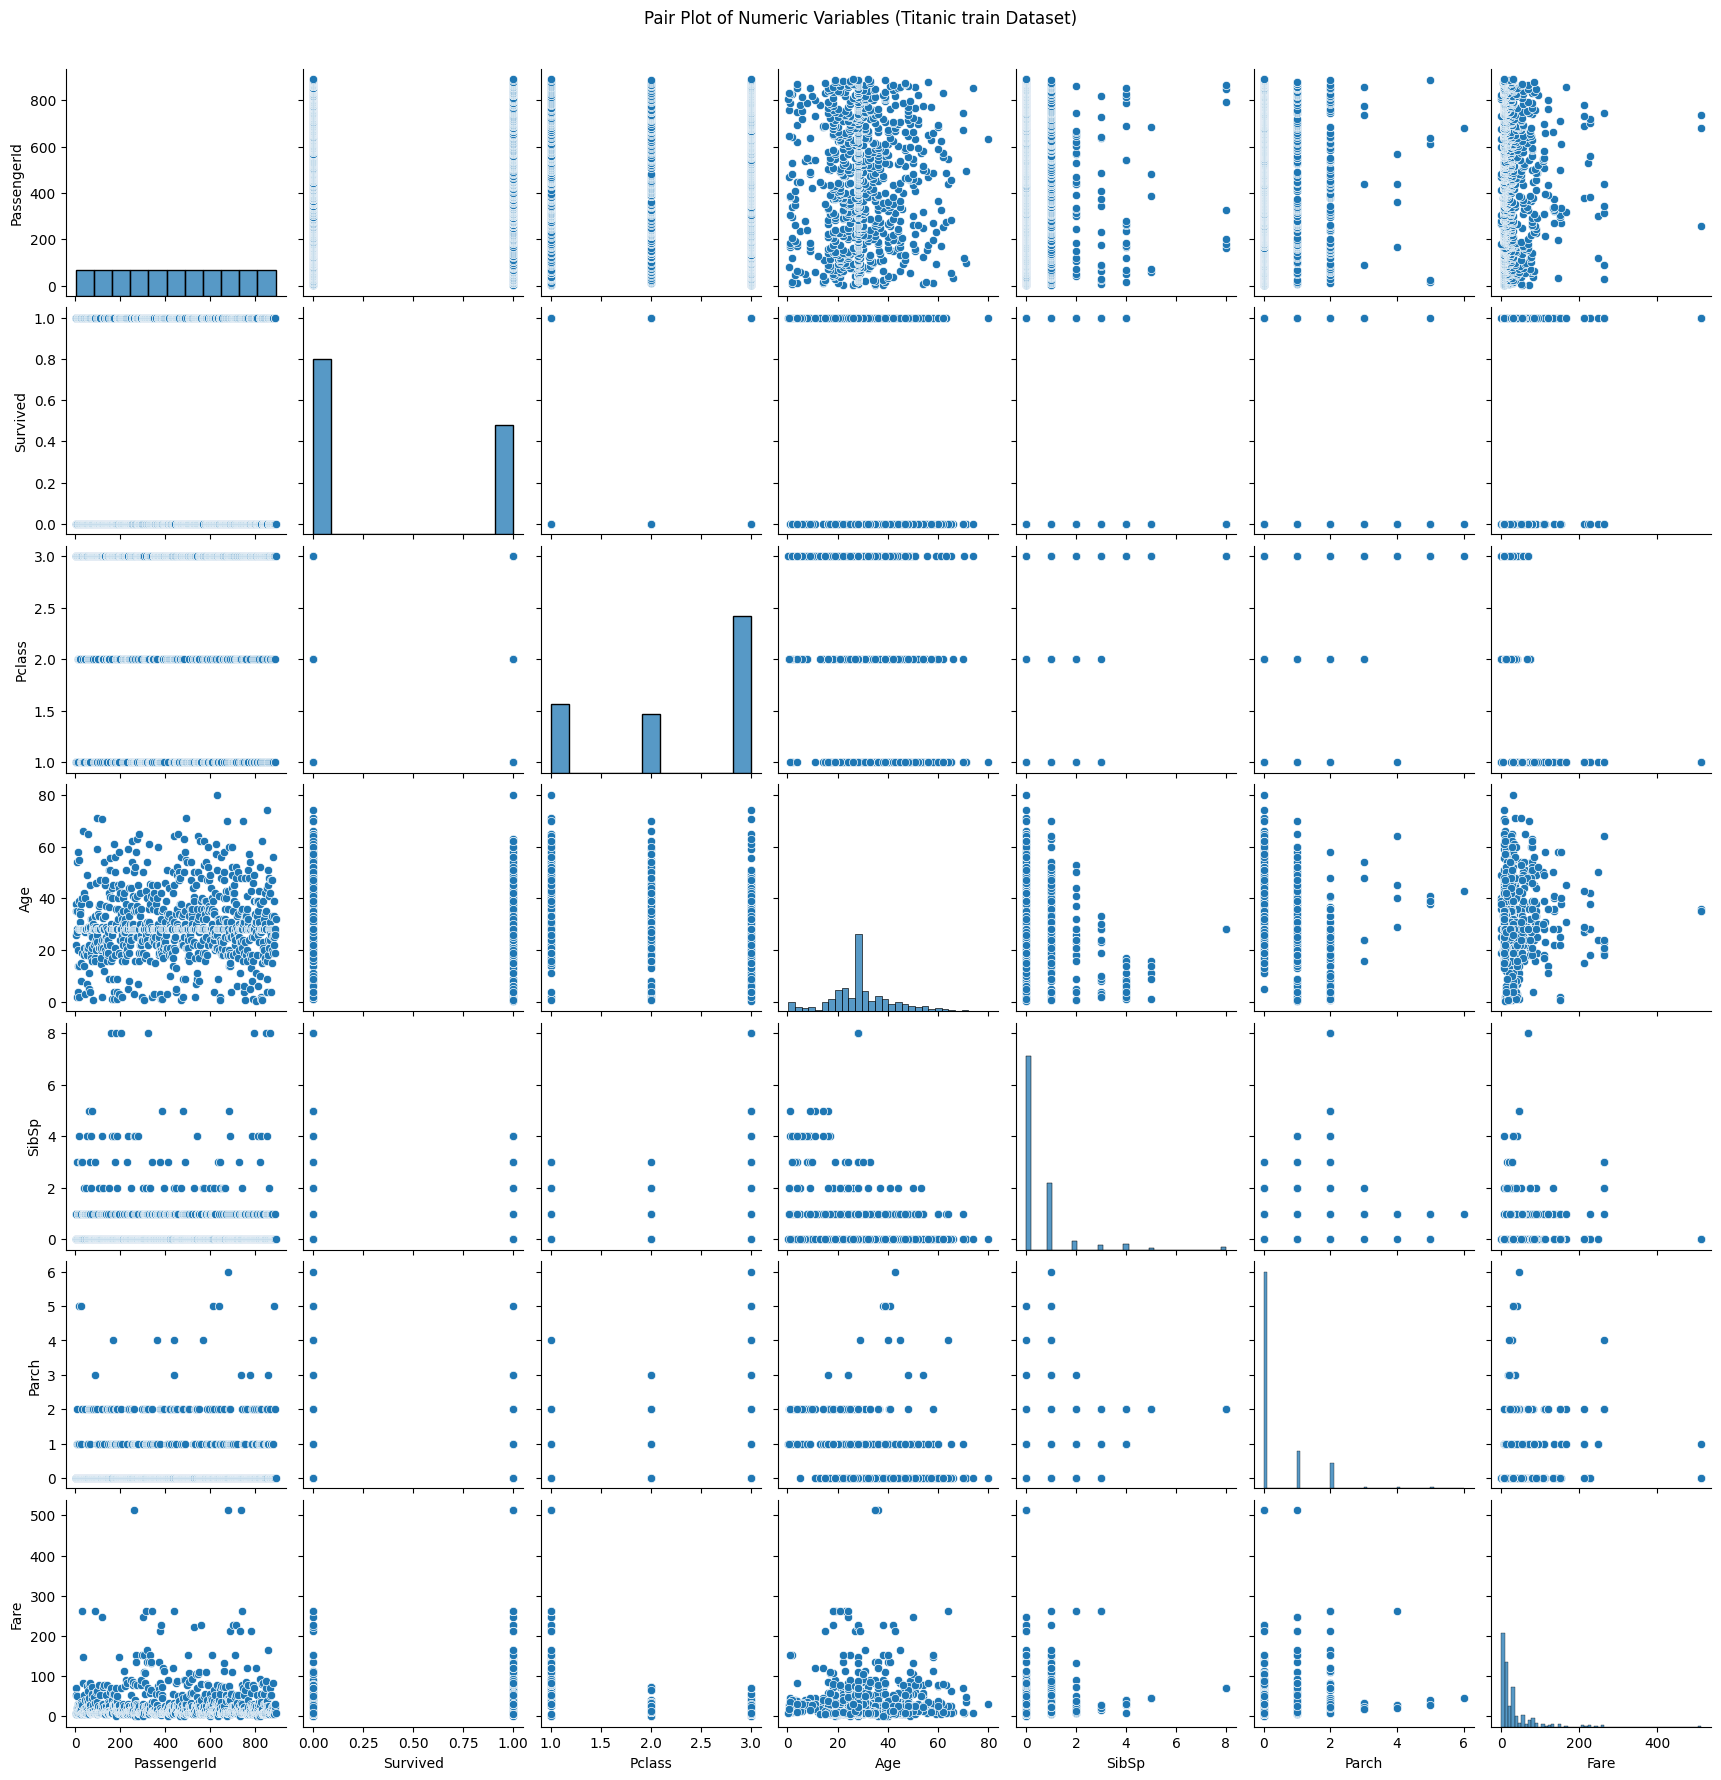

In [20]:
# pair plots
sns.pairplot(data_train_numeric)
plt.suptitle('Pair Plot of Numeric Variables (Titanic train Dataset)', y=1.02)
plt.show()

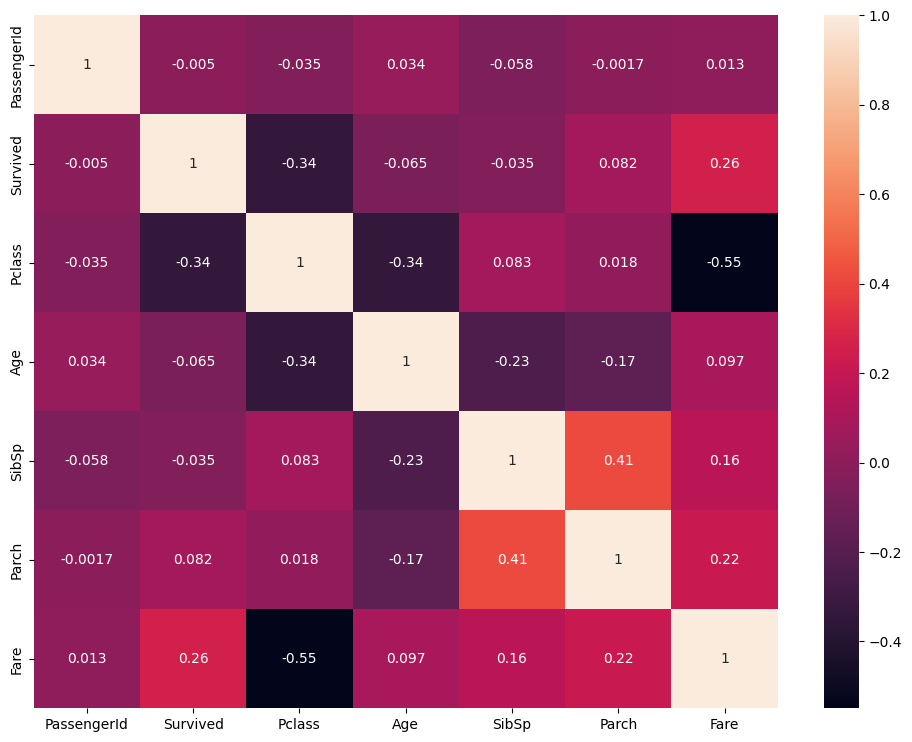

In [21]:
#correlation heatmap

plt.figure(figsize=(12,9))
sns.heatmap(data_train.corr(numeric_only=True),annot=True)
plt.show()

In [22]:
data_train = data_train.drop(['PassengerId','Name','Ticket'],axis=1)# because of they are not important

In [23]:
# EDA for data_train

In [24]:
data_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [25]:
data_test.fillna({'Age' : data_test['Age'].median()},inplace=True)

In [26]:
data_test.fillna({'Fare' : data_test['Fare'].median()},inplace=True)

In [27]:
# droping cabin column because more than 70% values or nan

data_test.drop(columns='Cabin',inplace=True)

In [28]:
data_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [29]:
data_test.duplicated().sum()

np.int64(0)

In [30]:
data_test = data_test.drop(['PassengerId','Name','Ticket'],axis=1)

In [31]:
data_test.describe()

,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000
mean,2.265550,29.599282,0.447368,0.392344,35.576535
std,0.841838,12.703770,0.896760,0.981429,55.850103
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,23.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,35.750000,1.000000,0.000000,31.471875
max,3.000000,76.000000,8.000000,9.000000,512.329200


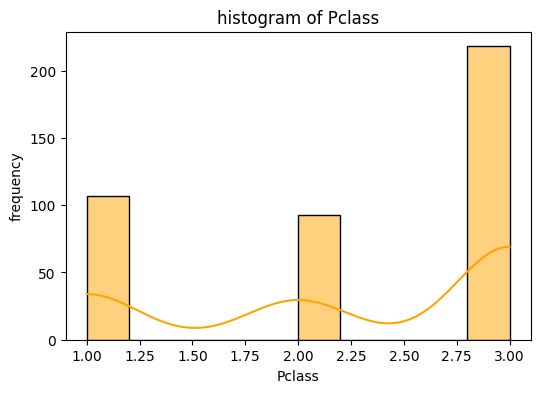

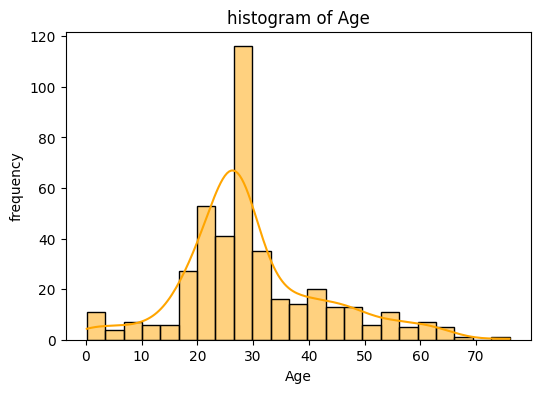

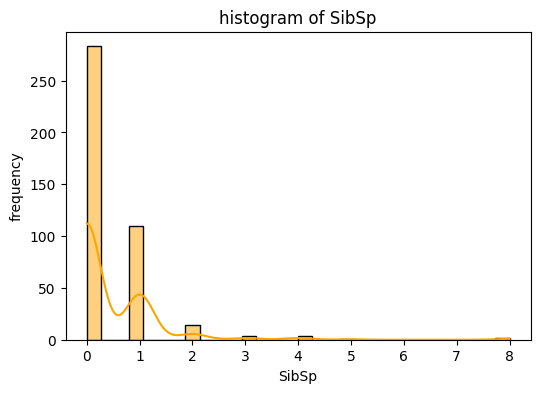

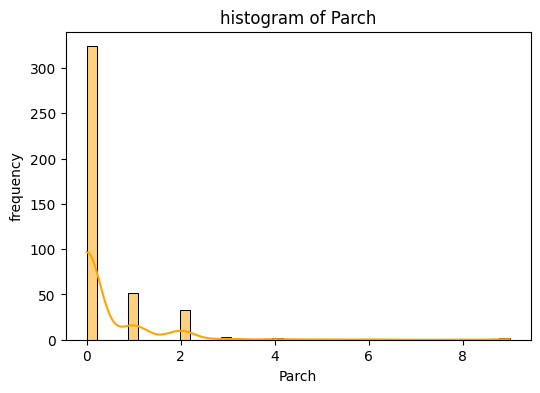

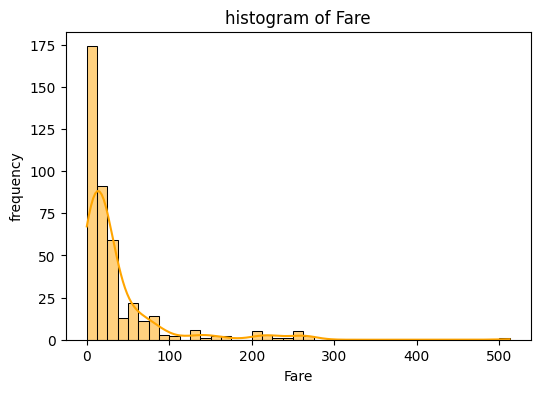

In [32]:
#creating histogram
data_test_numeric = data_test._get_numeric_data()
for col in data_test_numeric.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data_test_numeric[col],kde=True,color='orange',edgecolor='black')
    plt.title(f'histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

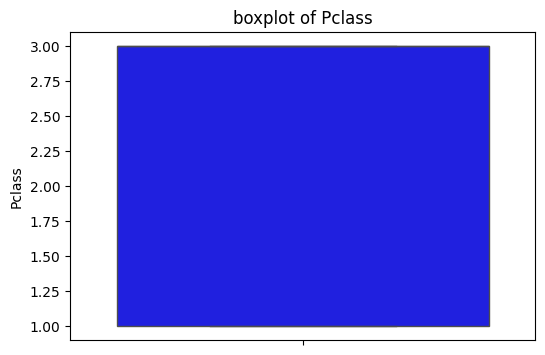

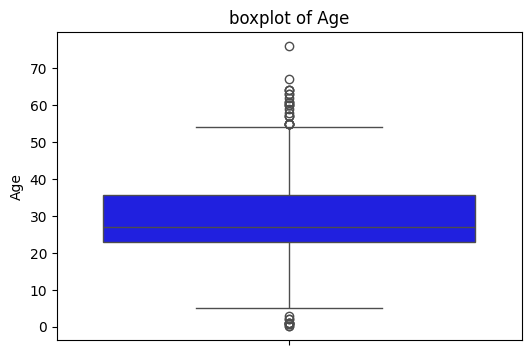

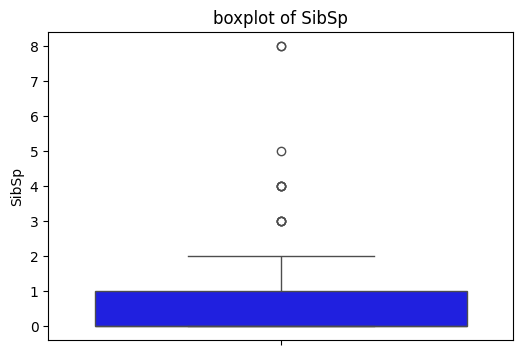

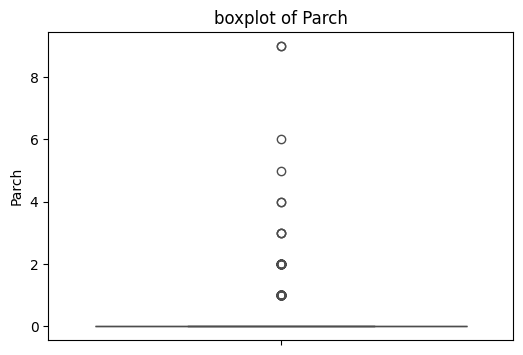

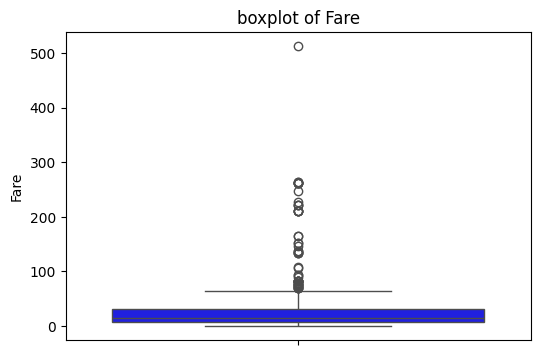

In [33]:
#Create boxplots for to identify outliers.

for col in data_test_numeric.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data_test_numeric[col],color='blue')
    plt.title(f'boxplot of {col}')
    plt.show()

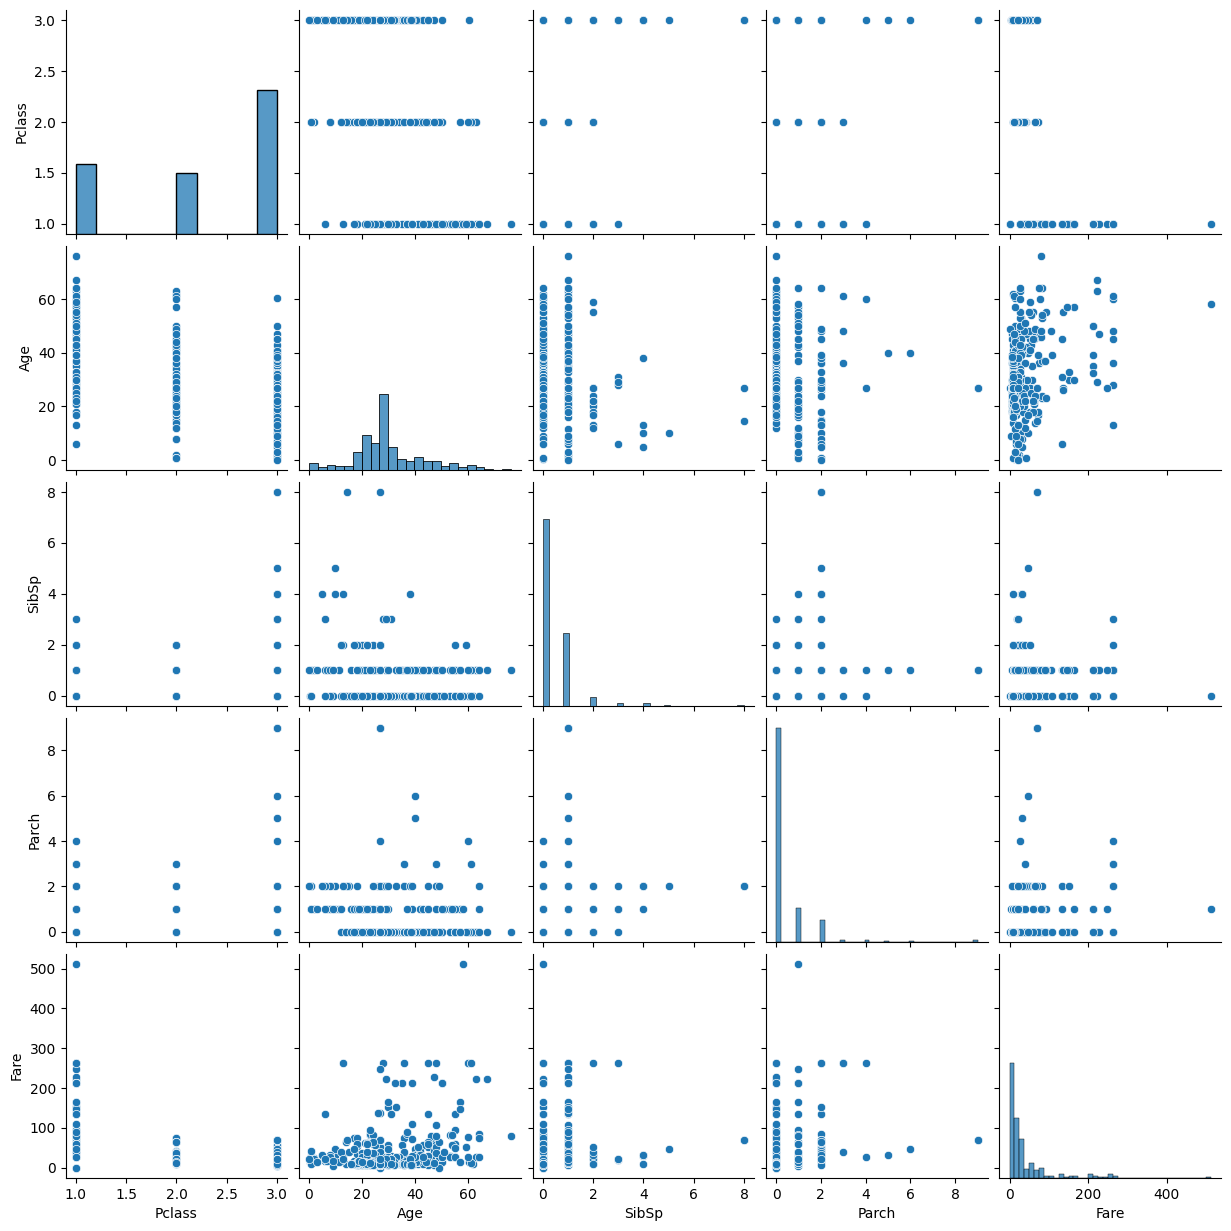

In [34]:
#pairplot

sns.pairplot(data_test_numeric)
plt.show()

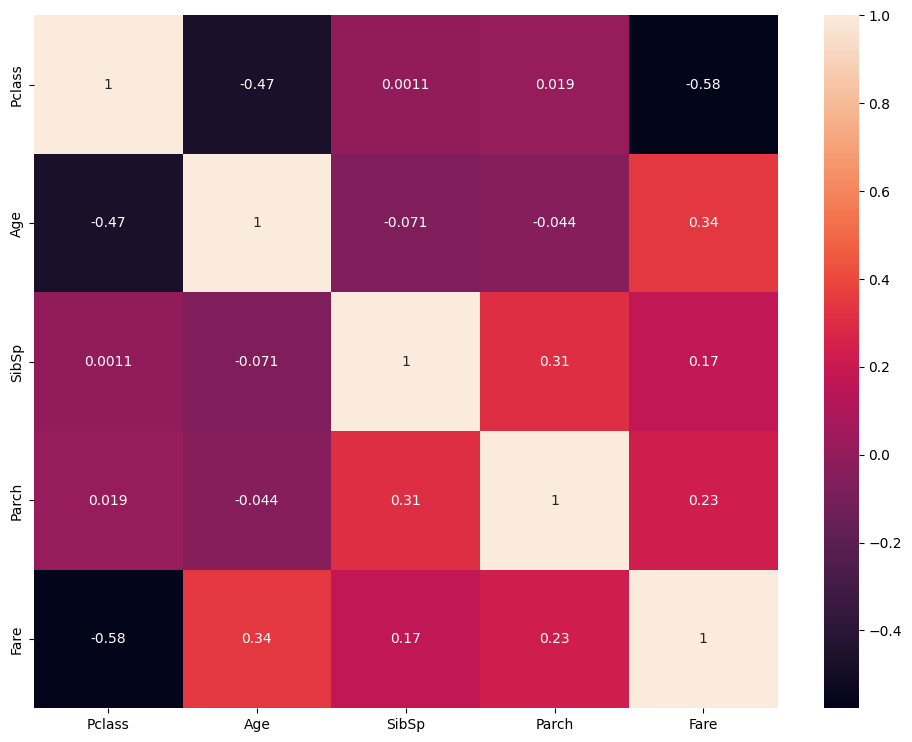

In [35]:
#correlation heatmap

plt.figure(figsize=(12,9))
sns.heatmap(data_test_numeric.corr(numeric_only=True),annot=True)
plt.show()

### 2. Data Preprocessing:

In [36]:
gender_map = {
    'male' : 0,
    'female' : 1
}
data_train['Sex'] = data_train['Sex'].map(gender_map)

In [37]:
embarked_map = {
    'S' : 0,
    'C' : 1,
    'Q' : 2
}
data_train['Embarked'] = data_train['Embarked'].map(embarked_map)

In [38]:
data_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0
887,1,1,1,19.0,0,0,30.0000,0
888,0,3,1,28.0,1,2,23.4500,0
889,1,1,0,26.0,0,0,30.0000,1


#### Encoding Catgorical test data

In [39]:
gender_map = {
    'male' : 0,
    'female' : 1
}
data_test['Sex'] = data_test['Sex'].map(gender_map)

In [40]:
embarked_map = {
    'S' : 0,
    'C' : 1,
    'Q' : 2
}
data_test['Embarked'] = data_test['Embarked'].map(embarked_map)

In [41]:
data_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,34.5,0,0,7.8292,2
1,3,1,47.0,1,0,7.0000,0
2,2,0,62.0,0,0,9.6875,2
3,3,0,27.0,0,0,8.6625,0
4,3,1,22.0,1,1,12.2875,0
...,...,...,...,...,...,...,...
413,3,0,27.0,0,0,8.0500,0
414,1,1,39.0,0,0,108.9000,1
415,3,0,38.5,0,0,7.2500,0
416,3,0,27.0,0,0,8.0500,0


### 3. Model Building:

In [42]:
X = data_train.iloc[:,1:]
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,0
887,1,1,19.0,0,0,30.0000,0
888,3,1,28.0,1,2,23.4500,0
889,1,0,26.0,0,0,30.0000,1


In [43]:
y = data_train['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(712, 7) (179, 7) (712,) (179,)


In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4. Model Evaluation:

In [47]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

In [48]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [49]:
a = accuracy_score(y_test,y_pred)
p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_pred_proba)
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

In [50]:
print('model evaluation')
print(f'accuracy : {a:.2f}')
print(f'precision : {p:.2f}')
print(f'recall : {r:.2f}')
print(f'f1-score : {f1:.2f}')
print(f'roc-auc : {roc_auc:.2f}')
print(f'confusion matrix :\n',cm)
print(f'classification report :\n', cr)

model evaluation
accuracy : 0.80
precision : 0.77
recall : 0.73
f1-score : 0.75
roc-auc : 0.88
confusion matrix :
 [[89 16]
 [20 54]]
classification report :
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



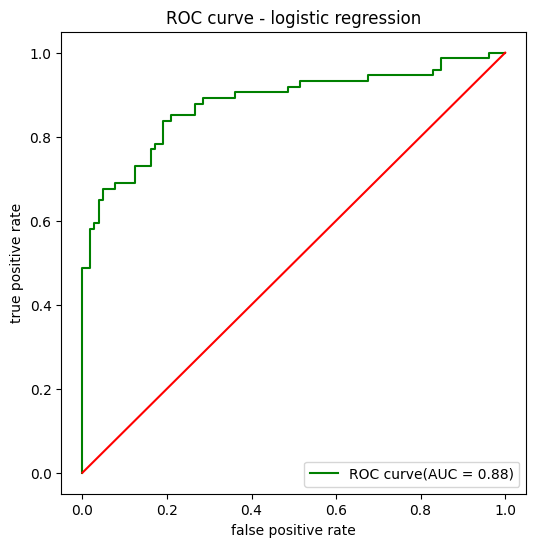

In [51]:
# Visualize the ROC curve.

fpr,tpr,threshold = roc_curve(y_test,y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f'ROC curve(AUC = {roc_auc:.2f})',color='green')
plt.plot([0,1],[0,1],linestyle='-',color='red')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve - logistic regression')
plt.legend(loc = 'lower right')
plt.show()

### 5. Interpretation:

In [52]:
import statsmodels.api as sm

In [53]:
X = sm.add_constant(X)
logit_model = sm.Logit(y,X)
results = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.441226
         Iterations 6


In [54]:
coef = results.params
p_values = results.pvalues
odds_ratios = np.exp(coef)

In [55]:
summary_table = pd.DataFrame({
    'feature' : coef.index,
    'coefficient' : coef.values,
    'odds ration' : odds_ratios.values,
    'p-value' : p_values.values,
    'significant (p<0.05)' : p_values < 0.05
})
print(summary_table)

           feature  coefficient  odds ration       p-value  \
const        const     2.189090     8.927086  4.985880e-06   
Pclass      Pclass    -1.122733     0.325389  2.020050e-15   
Sex            Sex     2.716896    15.133282  3.098145e-42   
Age            Age    -0.039496     0.961274  4.135601e-07   
SibSp        SibSp    -0.329272     0.719447  2.442257e-03   
Parch        Parch    -0.085233     0.918298  4.703993e-01   
Fare          Fare     0.002229     1.002231  3.451503e-01   
Embarked  Embarked     0.243307     1.275460  8.649184e-02   

          significant (p<0.05)  
const                     True  
Pclass                    True  
Sex                       True  
Age                       True  
SibSp                     True  
Parch                    False  
Fare                     False  
Embarked                 False  


### 6. Deployment with Streamlit:

In [56]:
import pickle

In [57]:
from pickle import dump

In [58]:
filename = 'Logistic_Regression.sav'
pickle.dump(model,open(filename,'wb'))

In [60]:
loaded_model = pickle.load(open(r'C:\Users\Raghavendra G N\python_practice\Logistic_Regression.sav','rb'))

In [61]:
import streamlit as st

st.title('A Logistic Regression Model')
st.write('Titanic survival prediction')
st.write('Enter passenger details to predict if they would survive or not')

#creating function

def get_input():

    #input fields

    pclass = st.selectbox('Passenger class (pclass)',[1,2,3])
    sex = st.selectbox('sex',['male','female'])
    age = st.number_input('age',min_value=0,max_value=100,value=25)
    sibsp = st.number_input('number of siblings/spouses (sibsp)',min_value=0,max_value=10,value=0)
    parch = st.number_input('number of parents/children (parch)',min_value=0,max_value=10,value=0)
    fare = st.number_input('fare',min_value=0.0,max_value=600.0,value=32.0)
    embarked = st.selectbox('embarked port',['C = Cherbourg (1)','Q = Queenstown (2)','S = Southampton (0)'])   

     #encode categorical variables

    sex = 1 if sex == 'female' else 0

    if 'Cherbourg' in embarked:
        embarked = 1
    elif 'Queenstown' in embarked:
        embarked = 2
    else:
        embarked = 0

    data_dict = {
        'Pclass' : pclass, 
        'Sex' : sex,
        'Age' : age,
        'SibSp' : sibsp,
        'Parch' : parch,
        'Fare' : fare,
        'Embarked' : embarked
    }

    #convert to dataframe

    input_data = pd.DataFrame(data_dict, index=[1])
    return input_data

features = get_input()

#predict on button click

if st.button('predict survival'):
    st.write('input features')
    st.write(features)

    res = loaded_model.predict(features)[0]
    proba = loaded_model.predict_proba(features)[0][1]

    st.write('prediction result')
    if res == 1:
        st.write(f'Survived! (probability : {proba:.2f})')
    else:
        st.write(f'did not survive (probability : {proba:.2f})')


2026-04-16 22:45:18.384 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.585 
  command:

    streamlit run C:\Users\Raghavendra G N\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-16 22:45:21.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.591 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.593 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 22:45:21.599 Thread 'MainT

In [62]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))

In [63]:
import pickle

# Save model
pickle.dump(model, open('model.pkl', 'wb'))

In [64]:
loaded_model = pickle.load(open('model.pkl', 'rb'))

## Interview Questions:

### What is the difference between precision and recall?
     precision
     formula = TP/(TP+FP)
     meaning = out of all predicted positives, how many are actually positives
     focus = reliability of positive predictions
     Example = disease test of 100 predicted sick, 80 are actually sick -> precision = 80%

     recall
     formula = TP/(TP+FN)
     meaning = out of all actual positives, how many did the model correctly predict?
     focus = coverage of actual positives
     Example = disease test of 100 truly sick, model catches 90 -> recall = 90%

### What is cross-validation, and why is it important in binary classification?
     cross-validation evealutes a model by training and testing it on multiple data folds, giving a more reliable performance estimate.in binary classification, it reduces overfitting, handles class imbalance, and ensures robust,fair evaluation even with small datasets.